In [1]:
import numpy as np

from factors import *

In [2]:
bt = BackTester(fc_name_list=['fac_cumret', 'fac_upperline', 'fac_winrate'],
                instrument_type='futures_continuous_contract',
                instrument_id_list = ['C0', 'FG0'],
                fc_freq = '1d',
                start_time='20230101',
                end_time='20260310',
                portfolio_adjust_method = '1D',
                interest_method = 'compound',
                risk_free_rate=False,
                n_jobs = 5
                )
# bt.backtest()

In [3]:
bt.data

,time,instrument_id,open,high,low,close,volume,position
0,2023-01-03,C0,2829,2842,2817,2840,301325,705314
1,2023-01-04,C0,2840,2877,2838,2875,489218,711148
2,2023-01-05,C0,2875,2882,2859,2878,341944,714472
3,2023-01-06,C0,2873,2892,2867,2886,368002,731213
4,2023-01-09,C0,2882,2895,2879,2890,306730,744645
...,...,...,...,...,...,...,...,...
1531,2026-03-04,FG0,1055,1055,1037,1038,985426,1321021
1532,2026-03-05,FG0,1039,1065,1038,1055,1177512,1263360
1533,2026-03-06,FG0,1056,1093,1052,1087,1384174,1256461
1534,2026-03-09,FG0,1098,1163,1090,1104,3221862,1165149


In [4]:
# self = bt
# Data = self.data
# df = Data.copy()
#
# df = df.sort_values(by='time', ascending=True)
# df = df.set_index(['time', 'instrument_id'])
#
# fc_class_list = [resolve_factor_class(fc_name) for fc_name in self.fc_name_list]
# f = lambda x: get_factor_value_for_one_factor(df, x)
#
# with Parallel(n_jobs=self.n_jobs) as parallel:
#     mapper_list = parallel(delayed(f)(fc_class) for fc_class in fc_class_list)
# mapper_list = [x.reset_index() for x in mapper_list]

In [5]:
bt.fc_name_with_param_list

['fac_cumret_1_50',
 'fac_cumret_1_100',
 'fac_cumret_2_50',
 'fac_cumret_2_100',
 'fac_cumret_3_50',
 'fac_cumret_3_100',
 'fac_upperline_10',
 'fac_upperline_30',
 'fac_winrate_10',
 'fac_winrate_20',
 'fac_winrate_30']

In [6]:
df = bt.data.copy()

In [ ]:
bt.performance_dc['C0']['fac_cumret_1_50']['daily_gross_ret'].copy()

In [ ]:
df[fc_col].ffill().fillna(0)

In [ ]:
bt.ts_performance_summary

In [ ]:
bt.plot_nav()

In [ ]:
from tsfresh.examples.robot_execution_failures import download_robot_execution_failures, \
    load_robot_execution_failures
download_robot_execution_failures()
timeseries, y = load_robot_execution_failures()

In [ ]:
print(timeseries.head())

In [ ]:
from tsfresh import extract_features
extracted_features = extract_features(timeseries, column_id="id", column_sort="time")

In [ ]:
timeseries

In [ ]:
extracted_features

In [ ]:
extracted_features.columns

In [ ]:
from factors.factor_auto_search import FactorGenerator

In [ ]:
from factors.factor_auto_search import FactorGenerator

fg = FactorGenerator(
    method='tsfresh',
    instrument_id_list=['C0', 'FG0'],
    fc_freq='1d',
    start_time='20230101',
    end_time='20260310',
    min_window_size=20,
    max_factor_count=200,
    tsfresh_profile='comprehensive',
    n_jobs=5,
    apply_rolling_norm=True,
    rolling_norm_window=30,
    rolling_norm_min_periods=20
)



In [ ]:
generated_df = fg.generate()
fc_subset = fg.generated_fc_name_list
print(len(fg.generated_fc_name_list))
fg.save_fc_value(fc_subset, file_name='tsfresh_fc_subset', file_format='parquet')
bt = fg.backtest(fc_name_list=fc_subset)

In [ ]:
len(fg.generated_fc_name_list)

In [ ]:
bt.plot_nav()

In [ ]:
fg.generated_fc_name_list

In [ ]:
fc_subset = ['close__maximum', 'close__absolute_maximum',
             'position__standard_deviation', 'position__variance']
config_path = fg.save_fc(fc_subset)
selected_fc = FactorGenerator.load_fc(config_path)
print(selected_fc)

In [ ]:
bt2 = fg.backtest_from_fc_config(config_path)

In [ ]:
bt2.performance_summary.loc[bt2.performance_summary['Instrument ID'] == 'C0']

In [ ]:
bt2.plot_nav()

# auto search

## 开始search

In [ ]:
from factors.factor_auto_search import FactorGenerator
fg = FactorGenerator(
    method='tsfresh',
    instrument_id_list=['C0'],
    fc_freq='1d',
    start_time='20230101',
    end_time='20260310',
    min_window_size=20,
    max_factor_count=20000,
    tsfresh_profile='comprehensive',
    n_jobs=5,
    apply_rolling_norm=True,
    rolling_norm_window=30,
    rolling_norm_min_periods=20
)
# one-step: mine + filter + save high-quality config
result = fg.auto_mine_select_and_save_fc(
    net_ret_threshold=0.05,
    sharpe_threshold=0.8,
    fc_package_name='tsfresh_high_quality_fc_20260317_new',
    require_all_instruments=False
)

## 检查信息泄露

In [ ]:
# 这个代码跑了一个半小时才跑出结果
leakage_check = fg.check_if_leakage(fc_name_list=result['selected_fc_name_list'], raise_error=True)

In [ ]:
leakage_check

In [ ]:
result.keys()

In [ ]:
result['selected_fc_name_list']

In [ ]:
fg.generated_data['close__mean_second_derivative_central']

In [ ]:
df_ps = result['bt'].performance_summary
df_ps.loc[(df_ps['Instrument ID'] == 'C0') & (df_ps['Factor Name'].isin(result['selected_fc_name_list'])]

In [4]:
result['bt'].plot_nav(fc_name=result['selected_fc_name_list'])

NameError: name 'result' is not defined

# tsfresh自动生成因子

In [6]:
from factors.factor_auto_search import FactorGenerator
fg1 = FactorGenerator(
    method='tsfresh',
    instrument_id_list=['C0'],
    fc_freq='1d',
    start_time='20230101',
    end_time='20260310',
    max_factor_count=20000,
    min_window_size=20,
    model_name='deepseek',
    llm_factor_count=5,
    llm_temperature=0.7,
    n_jobs=5,
    apply_rolling_norm=True,
    rolling_norm_window=30,
    rolling_norm_min_periods=20,
    calculate_baseline=True,
    version='test_20260317'
)

In [7]:
# one-step: mine + filter + save high-quality config
result1 = fg1.auto_mine_select_and_save_fc(
    net_ret_threshold=0.05,
    sharpe_threshold=0.8,
    require_all_instruments=False
)

全部生成的因子:  ['close__sum_values', 'close__median', 'close__mean', 'close__standard_deviation', 'close__variance', 'close__root_mean_square', 'close__maximum', 'close__absolute_maximum', 'close__minimum', 'high__sum_values', 'high__median', 'high__mean', 'high__standard_deviation', 'high__variance', 'high__root_mean_square', 'high__maximum', 'high__absolute_maximum', 'high__minimum', 'low__sum_values', 'low__median', 'low__mean', 'low__standard_deviation', 'low__variance', 'low__root_mean_square', 'low__maximum', 'low__absolute_maximum', 'low__minimum', 'open__sum_values', 'open__median', 'open__mean', 'open__standard_deviation', 'open__variance', 'open__root_mean_square', 'open__maximum', 'open__absolute_maximum', 'open__minimum', 'position__sum_values', 'position__median', 'position__mean', 'position__standard_deviation', 'position__variance', 'position__root_mean_square', 'position__maximum', 'position__absolute_maximum', 'position__minimum', 'volume__sum_values', 'volume__median', 'vo

,time,instrument_id,future_ret,close__sum_values,close__median,close__mean,close__standard_deviation,close__variance,close__root_mean_square,close__maximum,...,position__minimum,volume__sum_values,volume__median,volume__mean,volume__standard_deviation,volume__variance,volume__root_mean_square,volume__maximum,volume__absolute_maximum,volume__minimum
100,2023-06-05,C0,-0.004142,-1.181930,-1.252746,-1.181930,-0.216191,-0.374761,-1.185604,-1.577533,...,-1.965035,-2.725666,-2.096749,-2.725666,-0.476020,-0.490482,-2.609654,0.246300,0.246300,0.649399
101,2023-06-06,C0,-0.001134,-1.077588,-1.173856,-1.077588,-0.171374,-0.322109,-1.080404,-1.458801,...,-3.052301,-2.196691,-1.887599,-2.196691,-0.892886,-0.886987,-2.153643,0.859777,0.859777,0.599040
102,2023-06-07,C0,0.003785,-0.949007,-0.995456,-0.949007,-0.148324,-0.287206,-0.951117,-1.355192,...,-3.466164,-2.655955,-2.148109,-2.655955,-1.071185,-1.050566,-2.606628,0.802773,0.802773,-3.447034
103,2023-06-08,C0,-0.011689,-0.782502,-0.647460,-0.782502,-0.258304,-0.375258,-0.784607,-1.261461,...,-3.055203,-2.671714,-2.457972,-2.671714,-0.057811,-0.081985,-2.563227,0.748097,0.748097,-4.959013
104,2023-06-09,C0,-0.011828,-0.622734,-0.252130,-0.622734,-0.328854,-0.427613,-0.624785,-1.157547,...,-3.135238,-3.282312,-2.654990,-3.282312,-4.350473,-3.800349,-3.404676,-10.000000,-10.000000,-4.516482
105,2023-06-12,C0,0.008108,-0.524717,-0.200155,-0.524717,-0.586911,-0.636212,-0.527598,-1.082318,...,-2.626960,-2.651207,-2.316968,-2.651207,-2.680607,-2.519761,-2.694294,-4.862246,-4.862246,-3.406885
106,2023-06-13,C0,-0.002298,-0.410371,-0.145389,-0.410371,-0.834919,-0.821110,-0.414105,-1.012942,...,-2.285185,-2.184386,-1.703825,-2.184386,-2.251893,-2.148725,-2.215558,-3.513699,-3.513699,-2.819114
107,2023-06-14,C0,0.014587,-0.292319,-0.087266,-0.292319,-1.085939,-0.997790,-0.297117,-0.948376,...,-2.033155,-2.017557,-1.874272,-2.017557,-2.000296,-1.923422,-2.037562,-2.856198,-2.856198,-2.437582
108,2023-06-15,C0,0.012107,-0.113636,0.135789,-0.113636,-1.303298,-1.143832,-0.119857,-0.887786,...,-1.836454,-1.787970,-1.773927,-1.787970,-1.696006,-1.649618,-1.798553,-2.444229,-2.444229,-2.162346
109,2023-06-16,C0,0.000374,0.108943,0.322776,0.108943,-1.402558,-1.207269,0.101017,-0.564135,...,-1.676073,-1.494704,-1.347654,-1.494704,-1.626104,-1.579278,-1.513800,-2.152666,-2.152666,-1.950384


选中因子的回测结果: 


,Gross Return,Net Return,Gross Volatility,Net Volatility,Gross Sharpe,Net Sharpe,Gross Sortino,Net Sortino,Gross MaxDD,Net MaxDD,...,Net MaxDD (With Baseline),Gross Calmar (With Baseline),Net Calmar (With Baseline),Gross Win Rate (With Baseline),Net Win Rate (With Baseline),Turnover (With Baseline),Factor Name,Factor Freq,Fee,Instrument ID
year,,,,,,,,,,,,,,,,,,,,,
2023,0.203461,0.195618,0.191371,0.191367,1.063175,1.022216,1.446270,1.392160,0.147154,0.148991,...,"0.148991(0.178238,0.103057)","1.06318(-1.414,1.55276)","1.02222(-1.41429,1.55244)","0.421488(0.479339,0.504132)","0.417355(0.479339,0.504132)","0.12982(0.00413223,0.00413223)",close__sum_values,1d,0.0002,C0
2024,-0.169816,-0.176456,0.236169,0.236137,-0.719044,-0.747261,-0.787159,-0.831894,0.224273,0.230046,...,"0.230046(0.173031,0.0788619)","-0.719044(-0.718507,0.655333)","-0.747261(-0.718507,0.655333)","0.471074(0.421488,0.545455)","0.471074(0.421488,0.545455)","0.159755(0,0)",close__sum_values,1d,0.0002,C0
2025,-0.052116,-0.059794,0.172542,0.172530,-0.302049,-0.346569,-0.399643,-0.458298,0.169202,0.172687,...,"0.172687(0.127748,0.0838507)","-0.302049(-9.05212e-15,-0.0971796)","-0.346569(6.78909e-15,-0.0971796)","0.510288(0.497942,0.444444)","0.506173(0.497942,0.444444)","0.162645(0,0)",close__sum_values,1d,0.0002,C0
2026,0.459651,0.447834,0.114632,0.114636,4.009798,3.906589,5.684623,5.574751,0.044940,0.045141,...,"0.0451405(0.0156522,0.0730598)","4.0098(6.83492,-4.4005)","3.90659(6.83492,-4.4005)","0.560976(0.560976,0.390244)","0.560976(0.560976,0.390244)","0.165534(0,0)",close__sum_values,1d,0.0002,C0
all,0.000589,-0.007022,0.198061,0.198046,0.002974,-0.035457,0.003530,-0.042668,0.314044,0.322755,...,"0.322755(0.281865,0.142777)","0.00297415(-0.496911,0.409403)","-0.0354572(-0.497497,0.408748)","0.472656(0.471354,0.492188)","0.470052(0.471354,0.492188)","0.151545(0.00130208,0.00130208)",close__sum_values,1d,0.0002,C0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023,-0.047450,-0.060660,0.195142,0.194768,-0.243153,-0.311445,-0.312974,-0.401382,0.210027,0.216956,...,"0.216956(0.178238,0.103057)","-0.243153(-1.414,1.55276)","-0.311445(-1.41429,1.55244)","0.42562(0.479339,0.504132)","0.421488(0.479339,0.504132)","0.278328(0.00413223,0.00413223)",volume__minimum,1d,0.0002,C0
2024,-0.165537,-0.177358,0.174302,0.174601,-0.949718,-1.015792,-1.022499,-1.107939,0.268265,0.272584,...,"0.272584(0.173031,0.0788619)","-0.949718(-0.718507,0.655333)","-1.01579(-0.718507,0.655333)","0.471074(0.421488,0.545455)","0.471074(0.421488,0.545455)","0.282119(0,0)",volume__minimum,1d,0.0002,C0
2025,0.081326,0.063021,0.146526,0.146207,0.555026,0.431041,0.820883,0.637256,0.118299,0.122449,...,"0.122449(0.127748,0.0838507)","0.555026(-9.05212e-15,-0.0971796)","0.431041(6.78909e-15,-0.0971796)","0.452675(0.497942,0.444444)","0.452675(0.497942,0.444444)","0.341069(0,0)",volume__minimum,1d,0.0002,C0


选中因子的净值曲线: 


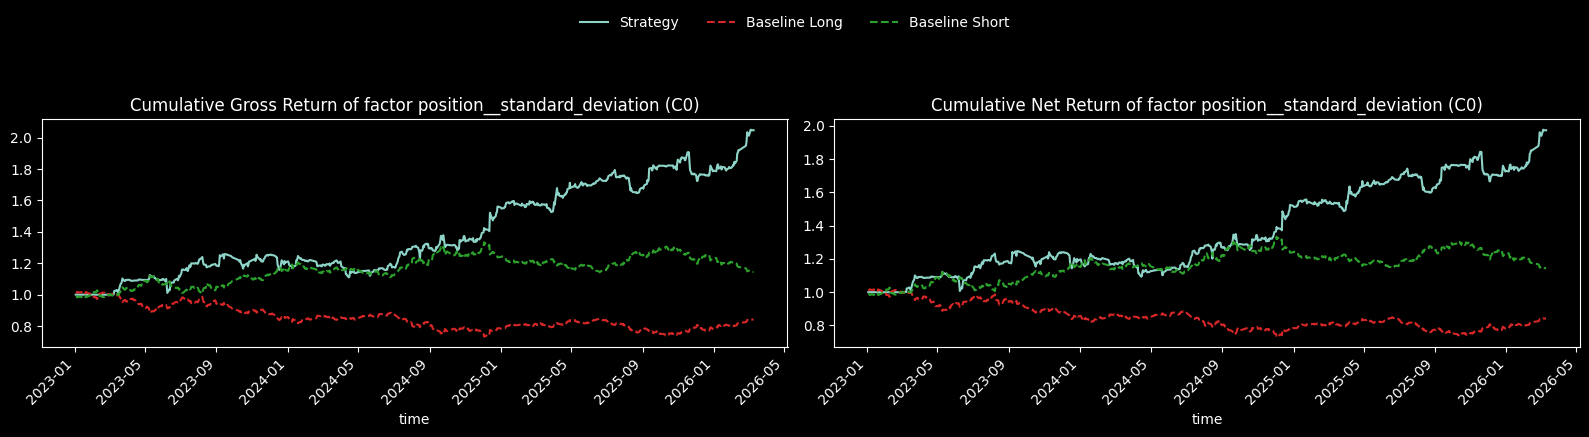

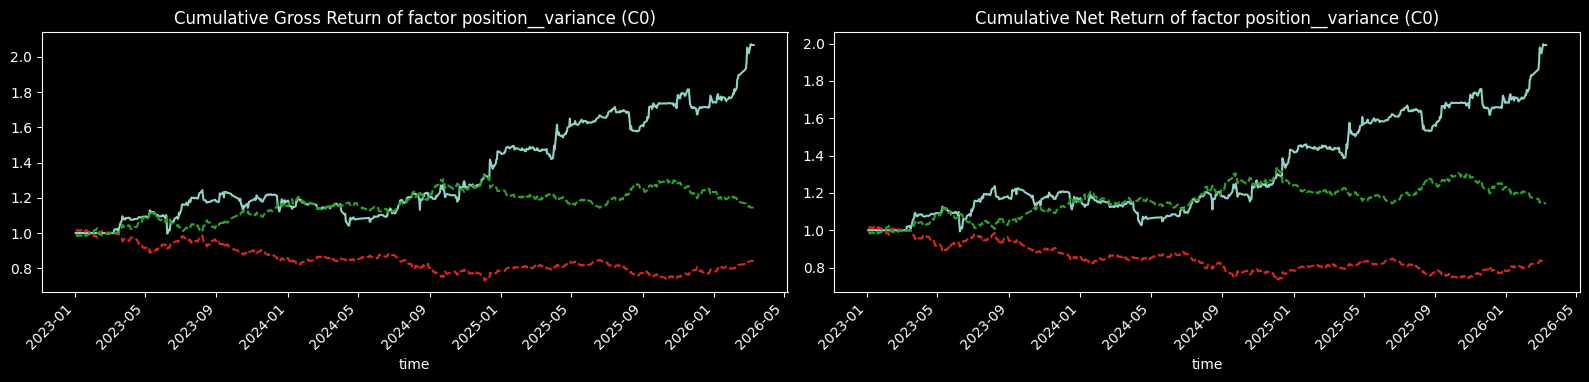

In [8]:
print("全部生成的因子: ", fg1.generated_fc_name_list)
print("选中的因子: ", result1['selected_fc_name_list'])
print("计算出的因子值: ")
display(fg1.generated_data.iloc[100:110])
print("选中因子的回测结果: ")
display(result1['bt'].performance_summary)
print("选中因子的净值曲线: ")
result1['bt'].plot_nav(fc_name=result1['selected_fc_name_list'],
                                                 show_baseline=True)

## llm自动生成因子

In [9]:
from factors.factor_auto_search import FactorGenerator
fg2 = FactorGenerator(
    method='llm_prompt',
    instrument_id_list=['C0'],
    fc_freq='1d',
    start_time='20200101',
    end_time='20241231',
    max_factor_count=200,
    min_window_size=20,
    model_name='deepseek',
    llm_factor_count=5,
    llm_temperature=0.7,
    n_jobs=5,
    apply_rolling_norm=True,
    rolling_norm_window=30,
    rolling_norm_min_periods=20,
    calculate_baseline=True,
    llm_user_requirement='多重视position和volume相关的逻辑，当然也可以结合一些价格数据。因为根据经验，position相关逻辑的因子效果比较好。因子逻辑可以适当复杂一些，因为简单的逻辑已经没有什么有用的因子了。',
    version='test_20260317'
)

In [ ]:
# one-step: mine + filter + save high-quality config
result2 = fg2.auto_mine_select_and_save_fc(
    net_ret_threshold=0.03,
    sharpe_threshold=0.5,
    require_all_instruments=False
)


全部生成的因子:  ['fac_volume_ratio_5', 'fac_volume_ratio_10', 'fac_volume_ratio_20', 'fac_atr_ratio_14', 'fac_atr_ratio_20', 'fac_atr_ratio_30', 'fac_price_volume_corr_10', 'fac_price_volume_corr_20', 'fac_price_volume_corr_30', 'fac_position_change_5', 'fac_position_change_10', 'fac_position_change_20', 'fac_ohlc_ratio_5', 'fac_ohlc_ratio_10', 'fac_ohlc_ratio_20', 'fac_volume_ma_ratio_5_20', 'fac_volume_ma_ratio_5_30', 'fac_volume_ma_ratio_5_60', 'fac_volume_ma_ratio_10_20', 'fac_volume_ma_ratio_10_30', 'fac_volume_ma_ratio_10_60', 'fac_volume_ma_ratio_20_20', 'fac_volume_ma_ratio_20_30', 'fac_volume_ma_ratio_20_60', 'fac_close_position_corr_10', 'fac_close_position_corr_20', 'fac_close_position_corr_30', 'fac_high_low_range_5', 'fac_high_low_range_10', 'fac_high_low_range_20', 'fac_volume_price_trend_5', 'fac_volume_price_trend_10', 'fac_volume_price_trend_20', 'fac_open_close_ratio_5', 'fac_open_close_ratio_10', 'fac_open_close_ratio_20']
选中的因子:  ['fac_position_change_10', 'fac_open_close

,time,instrument_id,future_ret,fac_volume_ratio_5,fac_volume_ratio_10,fac_volume_ratio_20,fac_atr_ratio_14,fac_atr_ratio_20,fac_atr_ratio_30,fac_price_volume_corr_10,...,fac_close_position_corr_30,fac_high_low_range_5,fac_high_low_range_10,fac_high_low_range_20,fac_volume_price_trend_5,fac_volume_price_trend_10,fac_volume_price_trend_20,fac_open_close_ratio_5,fac_open_close_ratio_10,fac_open_close_ratio_20
100,2023-06-05,C0,-0.004142,-0.513013,-0.770329,-0.975765,-0.637304,0.372588,0.870734,0.329440,...,-0.060787,-1.229098,-0.459289,0.726783,0.371436,-0.203043,-1.179631,0.988840,1.674695,1.680418
101,2023-06-06,C0,-0.001134,0.525580,-0.049415,-0.301395,-0.891391,0.258465,0.551187,0.671804,...,2.177406,-1.441797,-0.700877,0.561014,0.490155,-0.053281,-1.082870,0.486840,1.063167,1.713820
102,2023-06-07,C0,0.003785,-0.730078,-1.189675,-1.357735,-1.165654,-0.285145,0.053665,2.209239,...,3.735504,-1.603474,-1.171147,0.053810,0.619734,0.145581,-0.954831,0.502410,1.395916,2.033109
103,2023-06-08,C0,-0.011689,-0.817679,-1.300937,-1.466868,-1.200839,-0.770667,-0.277548,2.331731,...,2.844615,-1.859965,-1.414244,-0.399879,0.712712,0.346955,-0.796302,0.079596,1.235416,2.491560
104,2023-06-09,C0,-0.011828,-0.724335,-1.102613,-1.347199,-1.436381,-1.370873,-0.416141,-2.190658,...,2.311303,-1.866412,-1.960685,-0.987098,0.813827,0.493481,-0.654957,0.190908,0.748759,2.033572
105,2023-06-12,C0,0.008108,3.779556,3.551048,2.896438,-0.513125,-0.607605,1.670327,-4.918917,...,-1.763370,-0.991954,-1.467972,-0.921738,0.476643,0.457196,-0.587377,-0.783770,0.141248,1.577035
106,2023-06-13,C0,-0.002298,1.109790,1.306596,0.962595,-0.678419,-0.679792,1.659579,-3.671215,...,-1.361576,-0.556427,-1.272591,-0.909708,0.265233,0.446019,-0.505428,-0.106948,0.233827,1.537237
107,2023-06-14,C0,0.014587,-0.108255,0.302823,0.084375,-0.923739,-1.153345,1.215612,-2.985479,...,-1.348896,-0.640514,-1.441454,-1.352198,0.030472,0.423847,-0.423043,-0.152735,0.219907,1.329400
108,2023-06-15,C0,0.012107,0.519402,1.296747,1.186179,-1.176597,-1.257447,-0.081627,-2.076259,...,-0.901875,0.074976,-1.121364,-1.292705,-0.033499,0.458478,-0.288664,0.617260,0.404487,1.662146
109,2023-06-16,C0,0.000374,-0.127262,0.837607,0.819921,-1.137532,-1.064561,0.036533,-1.882358,...,-0.756537,0.406380,-0.939466,-1.054952,-0.020541,0.536054,-0.119871,1.057933,0.733808,1.675858


选中因子的回测结果: 


,Gross Return,Net Return,Gross Volatility,Net Volatility,Gross Sharpe,Net Sharpe,Gross Sortino,Net Sortino,Gross MaxDD,Net MaxDD,...,Net MaxDD (With Baseline),Gross Calmar (With Baseline),Net Calmar (With Baseline),Gross Win Rate (With Baseline),Net Win Rate (With Baseline),Turnover (With Baseline),Factor Name,Factor Freq,Fee,Instrument ID
year,,,,,,,,,,,,,,,,,,,,,
2023,-0.010116,-0.060724,0.133541,0.134405,-0.075751,-0.451796,-0.081043,-0.492134,0.100774,0.109721,...,"0.109721(0.178238,0.103057)","-0.075751(-1.414,1.55276)","-0.451796(-1.41429,1.55244)","0.442149(0.479339,0.504132)","0.413223(0.479339,0.504132)","1.03863(0.00413223,0.00413223)",fac_volume_ratio_5,1d,0.0002,C0
2024,-0.046540,-0.096482,0.111884,0.112108,-0.415965,-0.860613,-0.439843,-0.940356,0.123438,0.136812,...,"0.136812(0.173031,0.0788619)","-0.415965(-0.718507,0.655333)","-0.860613(-0.718507,0.655333)","0.491736(0.421488,0.545455)","0.46281(0.421488,0.545455)","1.06751(0,0)",fac_volume_ratio_5,1d,0.0002,C0
2025,0.250496,0.184548,0.117117,0.116844,2.138847,1.579449,3.890393,2.919063,0.076622,0.081827,...,"0.0818269(0.127748,0.0838507)","2.13885(-9.05212e-15,-0.0971796)","1.57945(6.78909e-15,-0.0971796)","0.506173(0.497942,0.444444)","0.469136(0.497942,0.444444)","1.07731(0,0)",fac_volume_ratio_5,1d,0.0002,C0
2026,-0.024991,-0.073151,0.060605,0.060479,-0.412357,-1.209520,-0.731062,-2.118944,0.020276,0.022068,...,"0.0220682(0.0156522,0.0730598)","-0.412357(6.83492,-4.4005)","-1.20952(6.83492,-4.4005)","0.414634(0.560976,0.390244)","0.414634(0.560976,0.390244)","1.0082(0,0)",fac_volume_ratio_5,1d,0.0002,C0
all,0.053426,-0.001324,0.118797,0.119078,0.449725,-0.011120,0.538457,-0.013701,0.123438,0.151057,...,"0.151057(0.281865,0.142777)","0.449725(-0.496911,0.409403)","-0.0111202(-0.497497,0.408748)","0.476562(0.471354,0.492188)","0.446615(0.471354,0.492188)","1.05834(0.00130208,0.00130208)",fac_volume_ratio_5,1d,0.0002,C0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023,0.076741,0.056462,0.144529,0.144510,0.530975,0.390714,0.604587,0.447539,0.085004,0.090362,...,"0.0903619(0.178238,0.103057)","0.530975(-1.414,1.55276)","0.390714(-1.41429,1.55244)","0.450413(0.479339,0.504132)","0.446281(0.479339,0.504132)","0.377339(0.00413223,0.00413223)",fac_open_close_ratio_20,1d,0.0002,C0
2024,-0.016474,-0.034425,0.157652,0.157683,-0.104496,-0.218318,-0.138524,-0.293816,0.119038,0.121007,...,"0.121007(0.173031,0.0788619)","-0.104496(-0.718507,0.655333)","-0.218318(-0.718507,0.655333)","0.438017(0.421488,0.545455)","0.429752(0.421488,0.545455)","0.365765(0,0)",fac_open_close_ratio_20,1d,0.0002,C0
2025,-0.069690,-0.091690,0.116740,0.116676,-0.596967,-0.785853,-0.805124,-1.071644,0.169741,0.184426,...,"0.184426(0.127748,0.0838507)","-0.596967(-9.05212e-15,-0.0971796)","-0.785853(6.78909e-15,-0.0971796)","0.44856(0.497942,0.444444)","0.432099(0.497942,0.444444)","0.480727(0,0)",fac_open_close_ratio_20,1d,0.0002,C0


选中因子的净值曲线: 


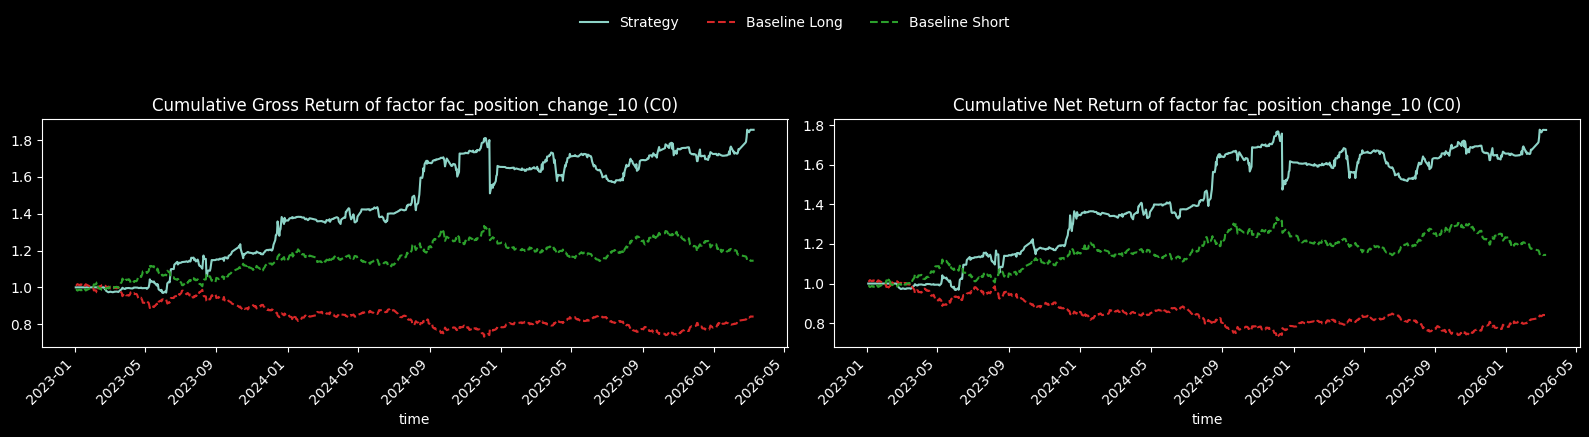

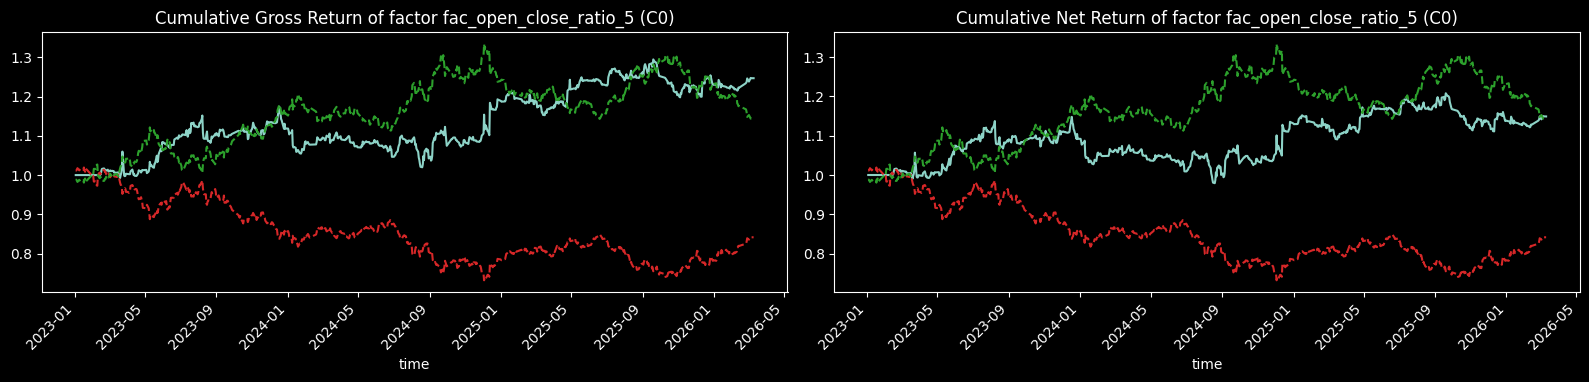

In [11]:
print("全部生成的因子: ", fg2.generated_fc_name_list)
print("选中的因子: ", result2['selected_fc_name_list'])
print("计算出的因子值: ")
display(fg2.generated_data.iloc[100:110])
print("选中因子的回测结果: ")
display(result2['bt'].performance_summary)
print("选中因子的净值曲线: ")
result2['bt'].plot_nav(fc_name=result2['selected_fc_name_list'],
                       show_baseline=True)

# 因子融合

In [2]:
from factors.factor_auto_search import FactorFusioner
ff = FactorFusioner(version_list='test_20260317',
                    fused_fc_name_suffix='test_20260317',
                    fusion_strategy='average_weight',
                    instrument_type='futures_continuous_contract',
                    instrument_id_list='C0',
                    fc_freq='1d',
                    start_time='20230101',
                    end_time='20260310',
                    apply_rolling_norm=True,
                    apply_rolling_norm_after_fusion=False,  # 融合后一般不再做rolling norm了
                    calculate_baseline=True)
ff.generate()

,time,instrument_id,future_ret,fac_fusion_average_weight_test_20260317
0,2023-01-03,C0,0.012324,0.000000
1,2023-01-04,C0,-0.000696,0.000000
2,2023-01-05,C0,0.003133,0.000000
3,2023-01-06,C0,0.002776,0.000000
4,2023-01-09,C0,-0.005536,0.000000
...,...,...,...,...
763,2026-03-04,C0,0.002942,1.944896
764,2026-03-05,C0,0.002515,1.760132
765,2026-03-06,C0,-0.000836,1.588889
766,2026-03-09,C0,NaN,1.217756


In [3]:
ff.raw_fc_value

,time,instrument_id,position__standard_deviation__tsfresh__test_20260317,position__variance__tsfresh__test_20260317,fac_position_change_10__llm_prompt__test_20260317,fac_open_close_ratio_5__llm_prompt__test_20260317,fac_fusion_average_weight_test_20260317
0,2023-01-03,C0,NaN,NaN,0.000000,0.000000,0.000000
1,2023-01-04,C0,NaN,NaN,0.000000,0.000000,0.000000
2,2023-01-05,C0,NaN,NaN,0.000000,0.000000,0.000000
3,2023-01-06,C0,NaN,NaN,0.000000,0.000000,0.000000
4,2023-01-09,C0,NaN,NaN,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...
763,2026-03-04,C0,2.635346,3.285591,1.085165,0.773484,1.944896
764,2026-03-05,C0,2.494789,3.082386,0.418825,1.044527,1.760132
765,2026-03-06,C0,2.387754,2.945959,0.346597,0.675244,1.588889
766,2026-03-09,C0,2.208355,2.677783,0.171108,-0.186221,1.217756


In [4]:
bt = ff.backtest()

In [5]:
bt.ts_performance_summary

,Gross Return,Net Return,Gross Volatility,Net Volatility,Gross Sharpe,Net Sharpe,Gross Sortino,Net Sortino,Gross MaxDD,Net MaxDD,...,Net MaxDD (With Baseline),Gross Calmar (With Baseline),Net Calmar (With Baseline),Gross Win Rate (With Baseline),Net Win Rate (With Baseline),Turnover (With Baseline),Factor Name,Factor Freq,Fee,Instrument ID
year,,,,,,,,,,,,,,,,,,,,,
2023,0.140636,0.128531,0.128110,0.128138,1.097776,1.003068,1.182719,1.092108,0.101994,0.103895,...,"0.103895(0.178238,0.103057)","1.09778(-1.414,1.55276)","1.00307(-1.41429,1.55244)","0.483471(0.479339,0.504132)","0.483471(0.479339,0.504132)","0.211706(0.00413223,0.00413223)",fac_fusion_average_weight_test_20260317,1d,0.0002,C0
2024,0.093768,0.082019,0.115427,0.115494,0.812355,0.710152,1.324148,1.160342,0.092811,0.098080,...,"0.0980802(0.173031,0.0788619)","0.812355(-0.718507,0.655333)","0.710152(-0.718507,0.655333)","0.475207(0.421488,0.545455)","0.466942(0.421488,0.545455)","0.217065(0,0)",fac_fusion_average_weight_test_20260317,1d,0.0002,C0
2025,0.100462,0.089621,0.091221,0.091230,1.101299,0.982363,1.763192,1.573854,0.066595,0.067266,...,"0.0672665(0.127748,0.0838507)","1.1013(-9.05212e-15,-0.0971796)","0.982363(6.78909e-15,-0.0971796)","0.485597(0.497942,0.444444)","0.477366(0.497942,0.444444)","0.197109(0,0)",fac_fusion_average_weight_test_20260317,1d,0.0002,C0
2026,1.084183,1.053612,0.114400,0.114426,9.477107,9.207813,21.551992,20.858205,0.013191,0.013301,...,"0.0133014(0.0156522,0.0730598)","9.47711(6.83492,-4.4005)","9.20781(6.83492,-4.4005)","0.609756(0.560976,0.390244)","0.609756(0.560976,0.390244)","0.296466(0,0)",fac_fusion_average_weight_test_20260317,1d,0.0002,C0
all,0.148629,0.136349,0.112835,0.112865,1.317227,1.208071,1.783909,1.661150,0.101994,0.105670,...,"0.10567(0.281865,0.142777)","1.31723(-0.496911,0.409403)","1.20807(-0.497497,0.408748)","0.488281(0.471354,0.492188)","0.483073(0.471354,0.492188)","0.213301(0.00130208,0.00130208)",fac_fusion_average_weight_test_20260317,1d,0.0002,C0


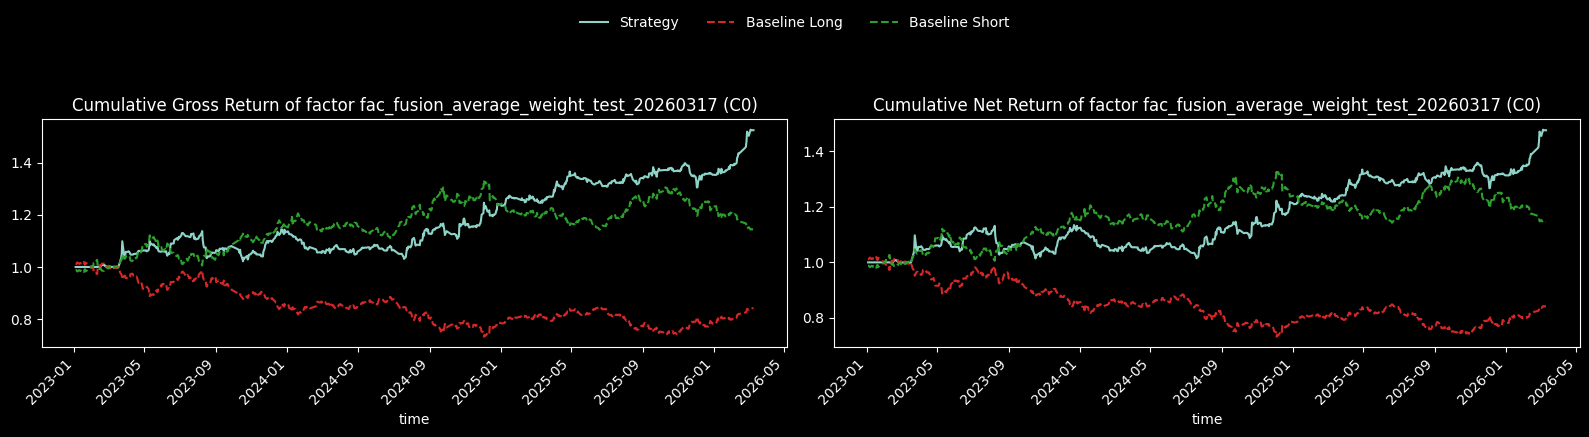

In [7]:
bt.plot_nav(show_baseline=True)